In [1]:
# ############################################################
# Level 1 — 정상 무리 + 이상치를 직접 만들어 탐지
# ############################################################
# ------------------------------------------------------------
# [목적] 도구 불러오기
# ------------------------------------------------------------
import numpy as np                                # 숫자·난수 만들기 (가짜 데이터 생성)
import pandas as pd                               # 표(DataFrame)로 확인하기
import matplotlib.pyplot as plt                   # 그래프 (점으로 그려 보기)
from sklearn.ensemble import IsolationForest      # 이상치 탐지 (빨리 고립되면 이상치)
%matplotlib inline

In [2]:
# ------------------------------------------------------------
# [목적] 데이터 만들기 — 정상 100개(가운데) + 이상치 8개(넓게)
# ------------------------------------------------------------
rng = np.random.default_rng(0)                    # 난수 고정 (매번 같은 데이터가 나오게)
normal   = rng.normal(0, 1, size=(100, 2))        # 정상 100개 (0 근처에 몰림)
outliers = rng.uniform(-6, 6, size=(8, 2))        # 이상치 8개 (-6~6으로 넓게 흩뿌림)
X = np.vstack([normal, outliers])                 # 위아래로 쌓기 (합쳐서 108개)

In [3]:
# ------------------------------------------------------------
# [데이터 살펴보기 · EDA] 만든 데이터를 표로 확인
# ------------------------------------------------------------
df = pd.DataFrame(X, columns=['x1', 'x2'])        # 좌표 2개짜리 표로 (열 이름 x1, x2)
print('데이터 크기(행, 열):', df.shape)           # (108, 2) 확인 (점 108개 × 좌표 2)
df.describe().round(2)                             # 값 범위 요약 (min/max가 벌어진 건 이상치 때문)

데이터 크기(행, 열): (108, 2)


,x1,x2
count,108.00,108.00
mean,-0.11,0.11
std,1.20,1.47
min,-5.13,-5.25
25%,-0.71,-0.59
50%,-0.04,0.10
75%,0.61,0.93
max,2.93,5.55


In [4]:
# ------------------------------------------------------------
# [목적] 학습+판정 -> 각 점에 -1/1 부여 (표에 열로)
# ------------------------------------------------------------
iso = IsolationForest(contamination=0.1, random_state=0)  # 모델 (이상치 약 10% 가정)
df['anomaly'] = iso.fit_predict(X)                # 판정 결과를 표에 새 열로 (-1=이상, 1=정상)
print('이상치로 탐지된 개수:', (df['anomaly'] == -1).sum())   # 개수 세기 (약 11개)

이상치로 탐지된 개수: 11


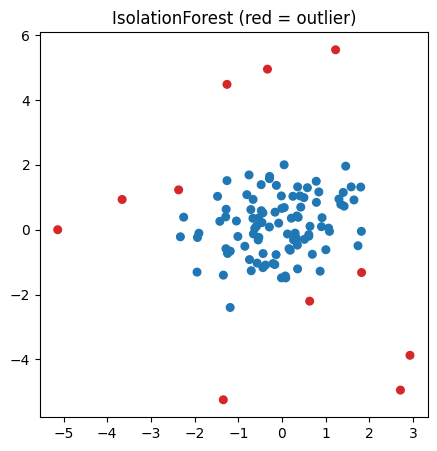

In [5]:
# ------------------------------------------------------------
# [목적] 2차원이라 눈으로 확인 — 정상=파랑, 이상치=빨강
# ------------------------------------------------------------
colors = df['anomaly'].map({1: 'tab:blue', -1: 'tab:red'})   # 판정에 따라 색 정하기
plt.figure(figsize=(5, 5))
plt.scatter(df['x1'], df['x2'], c=colors, s=30)   # 점 찍기 (색 = 정상/이상)
plt.title('IsolationForest (red = outlier)')      # 제목 (한글은 깨질 수 있어 영문)
plt.show()                                         # 화면에 출력

In [6]:
# ============================================================
# [결과 해석]
#  · 108개 중 약 11개를 이상치로 탐지 (contamination 0.1 = 약 10%)
#  · 그림에서 가운데 파란 무리 밖으로 벗어난 점들이 빨강(이상치)으로 잘 잡힘
#  · 일부러 심어둔 이상치 8개 부근을 대체로 맞힘
#  · 실전에선 어느 게 이상치인지 모른 채 찾는다 (여기선 이해를 위해 심어둠)
# ============================================================